In [1]:
import numpy as np
import crossSections as cross
import swarmParameters as swarm
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})
%matplotlib inline

# datasets
datasets = ["Biagi","BSR","Hayashi","IST-Lisbon","Morgan","Phelps","Puech","SIGLO","TRINITI"]
Nsets = len(datasets)

## Generate cross-section datasets with varying elastic collision in large energy range.

In [9]:
directory = './bolsig-sensitivity-elastic'
import subprocess
subprocess.run('mkdir -p %s/crs' % directory, shell=True)
subprocess.run('mkdir -p %s/input' % directory, shell=True)
subprocess.run('mkdir -p %s/output' % directory, shell=True)
subprocess.run('mkdir -p %s/data' % directory, shell=True)

largeE = 1.5e1

refset = datasets[0]
filename = "./crs/%s.txt" % refset
ref = cross.multipleCrossSections(filename)
for c in ref.crs:
    if ((c.colType==0)):
        mask = ((c.data[:,0] < largeE))
        temp = np.copy(c.data[mask,:])

for dataset in datasets[1:-2]:
    filename = "./crs/%s.txt" % dataset
    print("="*50)
    print("  Dataset = {0:s}".format(dataset))
    print("="*50)
    tmp = cross.multipleCrossSections(filename)
    for k, c in enumerate(tmp.crs):
        if ((c.colType==0)):
            mask = ((c.data[:,0] >= largeE))
            targetmf = np.copy(c.data[mask,:])
    for k, c in enumerate(ref.crs):
        if ((c.colType==0)):
            temp2 = np.append(temp,targetmf,axis=0)
            ref.crs[k].data = temp2[temp2[:,0].argsort()]
    filename = '%s/crs/%s-%s.txt' % (directory, refset,dataset)
    ref.writeLXCatFile(filename)

  Dataset = BSR
  Dataset = Hayashi
  Dataset = IST-Lisbon
  Dataset = Morgan
  Dataset = Phelps
  Dataset = Puech


### Visualized the generated cross-sections

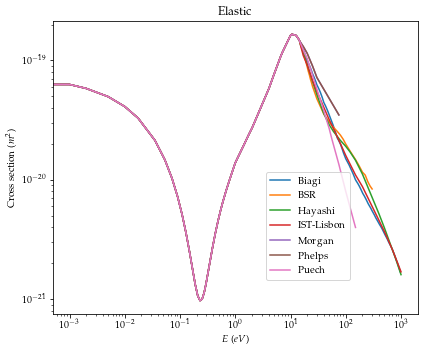

In [24]:
plt.figure(2)
h = []
for k, dataset in enumerate(datasets[:-2]):
    if (k==0):
        filename = "./crs/Biagi.txt"
    else:
        filename = "%s/crs/Biagi-%s.txt" % (directory, dataset)
    tmp = cross.multipleCrossSections(filename)

    for c in tmp.crs:
        if ((c.colType==0)):
            targetmf = c
            plt.loglog(c.data[:,0],c.data[:,1],'-')
            h += [dataset]
            
            crsFile = "%s/data/crs.%s.txt" % (directory, dataset)
            np.savetxt(crsFile, c.data)
plt.title('Elastic')
plt.xlabel('$E$ ($eV$)')
plt.ylabel('Cross section ($m^2$)')
# plt.xlim([1e1, 1e3])
fig = plt.gcf()
fig.set_size_inches(6, 5)
plt.tight_layout()
plt.legend(h,bbox_to_anchor=(.7, .5))
# plt.savefig('./ex2.lxcat.varying-lowE.png',dpi=500)
plt.show()

## Run bolsig with generated cross-sections

In [17]:
from input_writer import transport300K, writeInputFile
from copy import deepcopy
baseDict = deepcopy(transport300K)
baseDict['RUNSERIES'] = [1, 1.0e-3, 2000., 110, 3]

for k, dataset in enumerate(datasets[:-2]):
    if (k==0):
        crsFile = "./crs/Biagi.txt"
    else:
        crsFile = "%s/crs/Biagi-%s.txt" % (directory, dataset)
    outputFile = "%s/output/output-%s.dat" % (directory, dataset)
    inputFile = "%s/input/input-%s.dat" % (directory, dataset)
    writeInputFile(inputFile, baseDict, crsFile, outputFile)
    
    command = './bolsigminus %s' % inputFile
    process2 = subprocess.run(command, shell=True)

./crs/Biagi.txt
./bolsig-sensitivity-elastic/crs/Biagi-BSR.txt
./bolsig-sensitivity-elastic/crs/Biagi-Hayashi.txt
./bolsig-sensitivity-elastic/crs/Biagi-IST-Lisbon.txt
./bolsig-sensitivity-elastic/crs/Biagi-Morgan.txt
./bolsig-sensitivity-elastic/crs/Biagi-Phelps.txt
./bolsig-sensitivity-elastic/crs/Biagi-Puech.txt


## Read output files

In [18]:
swarmDatas = []
for dataset in datasets[:-2]:
    outputFile = "%s/output/output-%s.dat" % (directory, dataset)
    swarmDatas += [swarm.bolsigOutput(outputFile)]

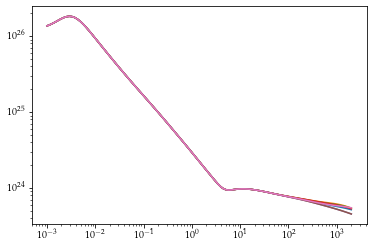

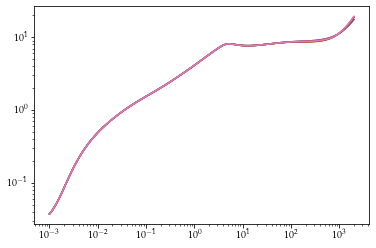

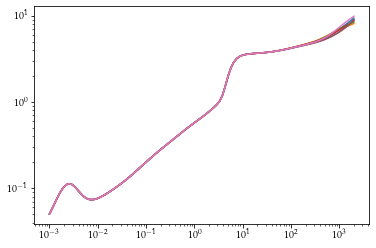

In [23]:
from swarmParameters import bolsigOutput

idx = 4
plt.figure(1)
for k, dataset in enumerate(datasets[:-2]):
    plt.loglog(swarmDatas[k].outputs[idx].data[:, 0], swarmDatas[k].outputs[idx].data[:, 1])
    
    dataFile = "%s/data/muN.%s.txt" % (directory, dataset)
    np.savetxt(dataFile, swarmDatas[k].outputs[idx].data)
    
idx = 5
plt.figure(2)
for k, dataset in enumerate(datasets[:-2]):
    plt.loglog(swarmDatas[k].outputs[idx].data[:, 0], swarmDatas[k].outputs[idx].data[:, 1] / swarmDatas[k].outputs[4].data[:, 1])
    
    dataFile = "%s/data/DLmu.%s.txt" % (directory, dataset)
    temp = np.copy(swarmDatas[k].outputs[idx].data)
    temp[:,1] /= swarmDatas[k].outputs[4].data[:, 1]
    np.savetxt(dataFile, temp)
    
idx = 18
plt.figure(3)
for k, dataset in enumerate(datasets[:-2]):
    plt.loglog(swarmDatas[k].outputs[idx].data[:, 0], swarmDatas[k].outputs[idx].data[:, 1] / swarmDatas[k].outputs[4].data[:, 1])

    dataFile = "%s/data/DTmu.%s.txt" % (directory, dataset)
    temp = np.copy(swarmDatas[k].outputs[idx].data)
    temp[:,1] /= swarmDatas[k].outputs[4].data[:, 1]
    np.savetxt(dataFile, temp)